Loaded 8 methods: ['ERM', 'Particle Ascent', 'ICNN', 'Dual(Wang et al., 2021)', 'WFR(Xu, 2025)', 'SVG', 'NN-DRO', 'PPA']


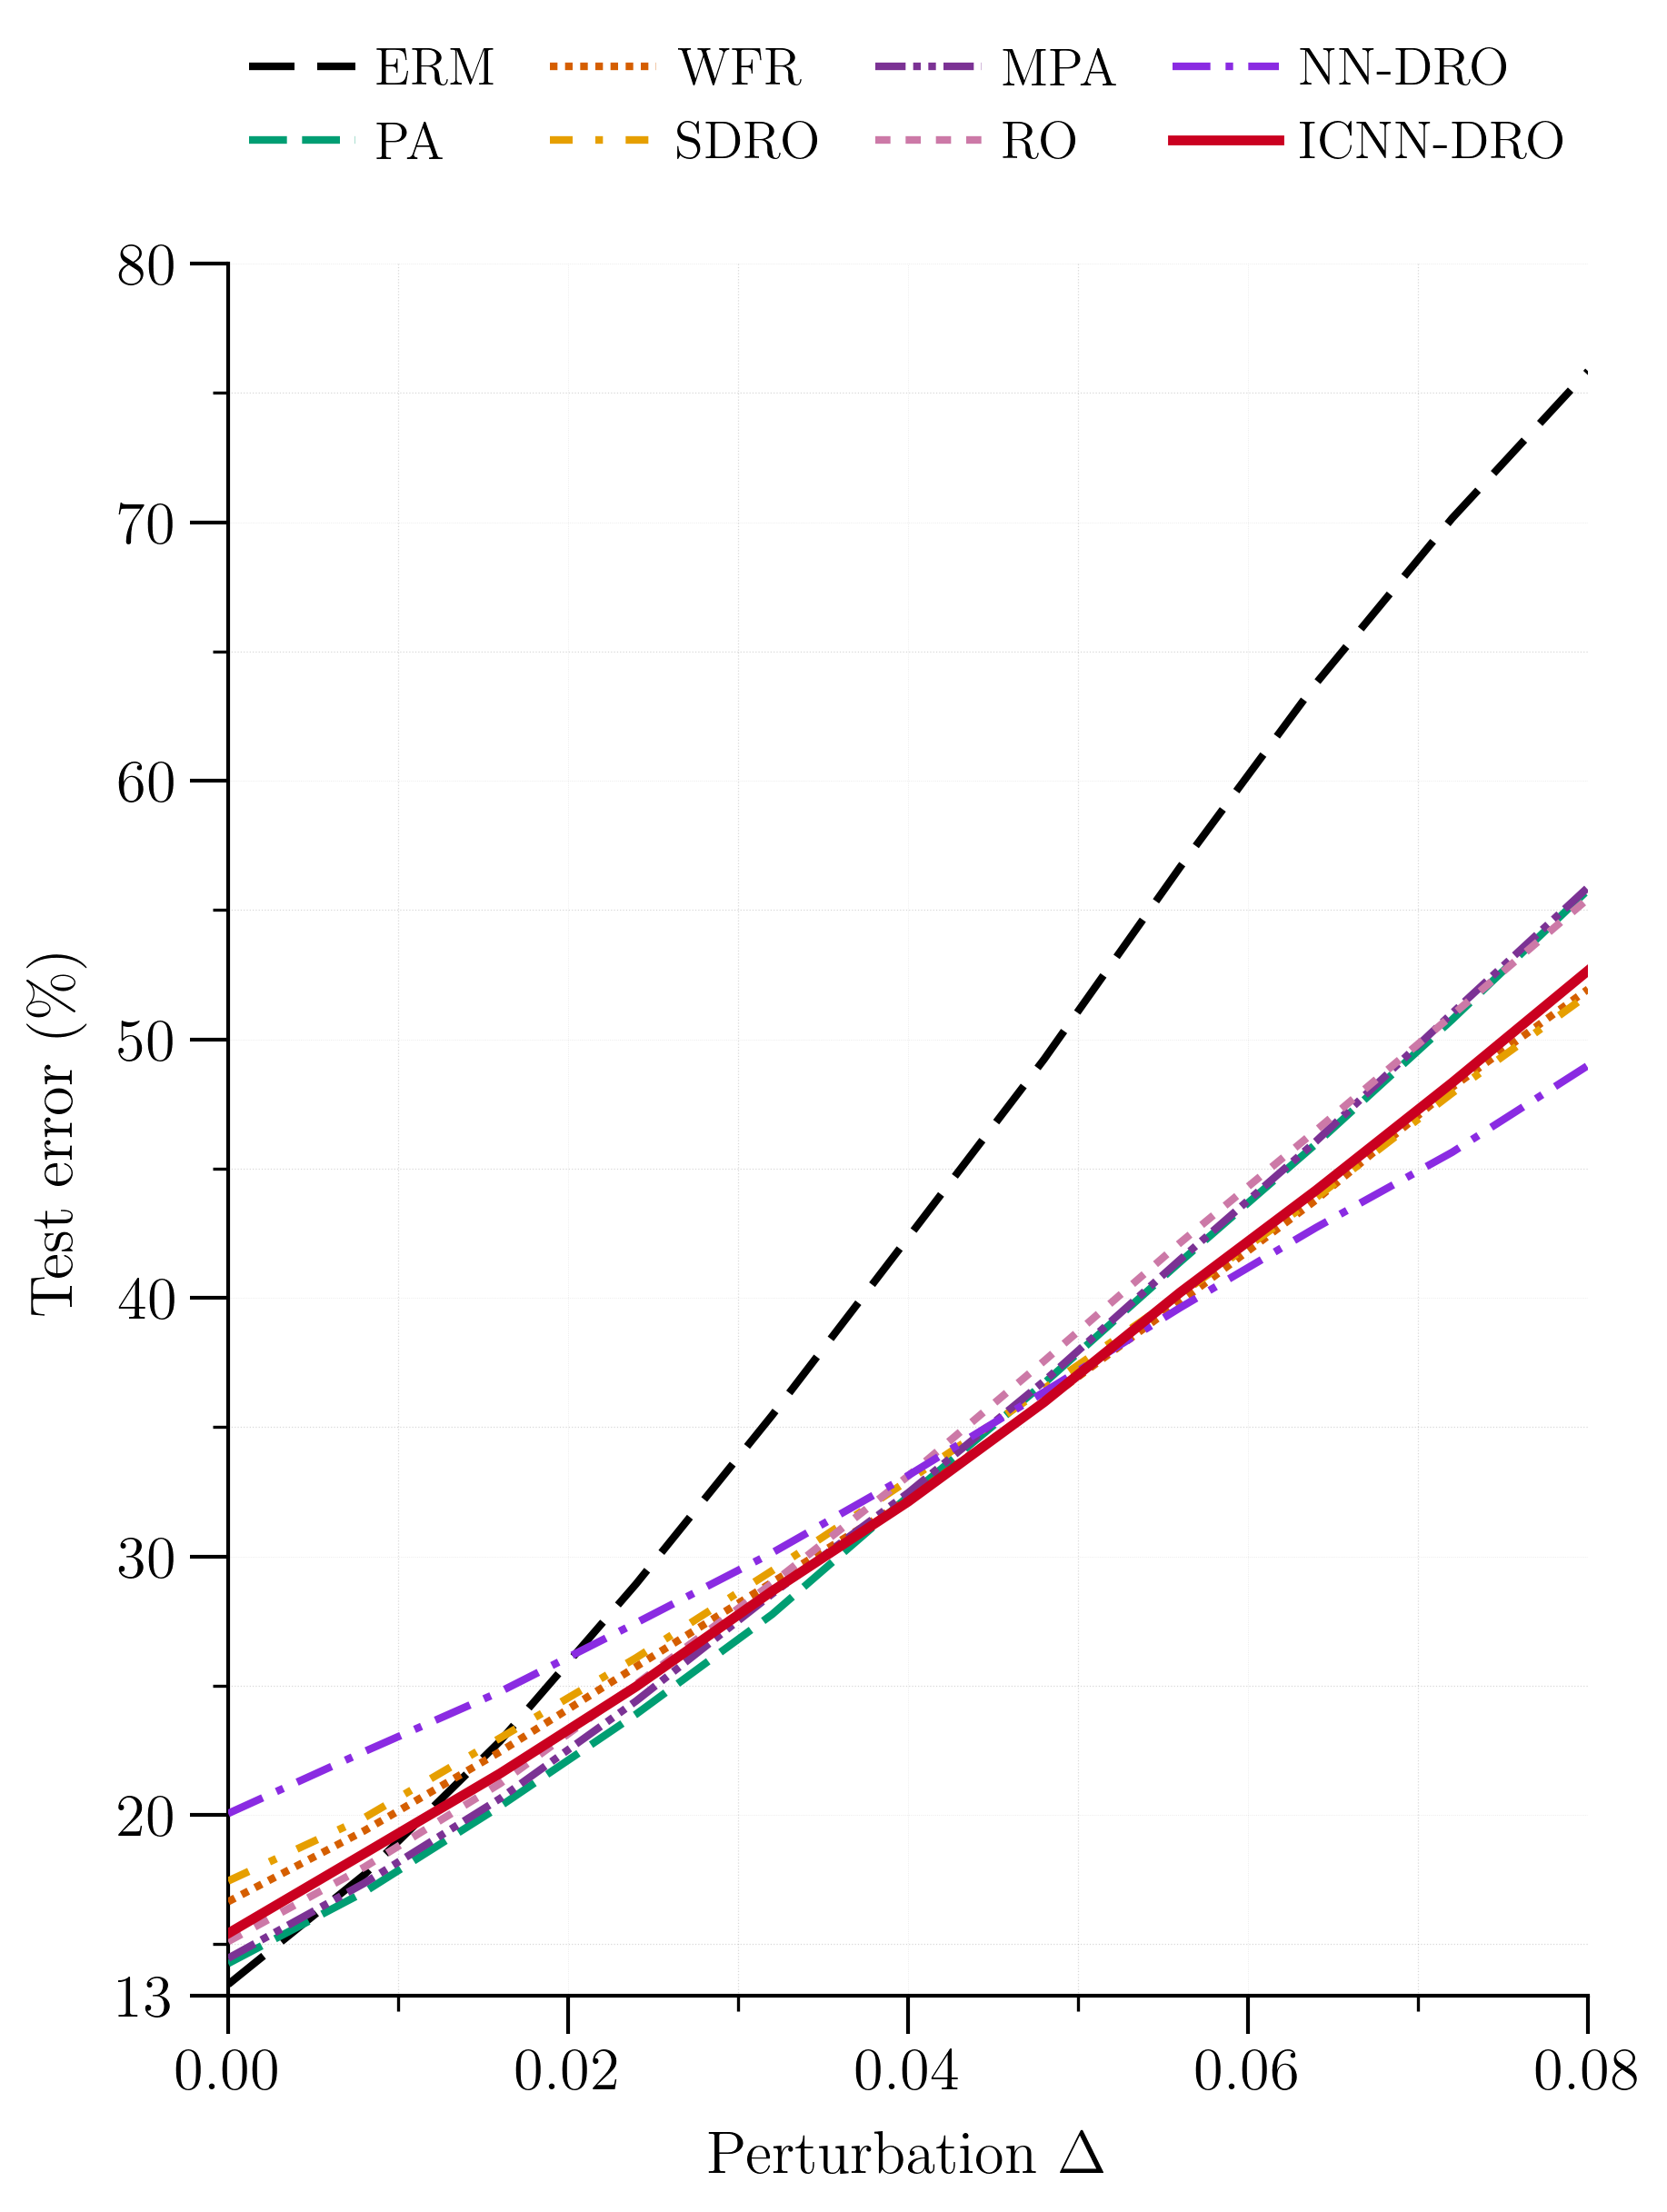

In [6]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── LaTeX / font configuration ────────────────────────────────────────────────
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "xtick.major.size": 10,
    "ytick.major.size": 10,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
    "axes.spines.right": False,
    "axes.spines.top": False,
})

# ── Load results from combined JSON ──────────────────────────────────────────
JSON_PATH = os.path.join(
    os.path.dirname(os.path.abspath("__file__")),
    "outputs_adversarial_multiclass_icnn",
    "results_tau=0.05_epsent=0.2_old.json",
)

with open(JSON_PATH) as f:
    payload = json.load(f)

perturbation_levels = np.array(payload["perturbation_levels"])
epsilon_attack_values = payload["epsilon_attack_values"]
raw_results = payload["results"]  # {method_key: [{eps_str: accuracy%, ...}, ...]}

# Method key -> display name  (matches adversarial_multiclass_icnn.py conventions)
METHOD_DISPLAY = {
    "SAA":    "ERM",
    "WRM":    "Particle Ascent",
    "WFR":    "WFR(Xu, 2025)",
    "Dual":   "Dual(Wang et al., 2021)",
    "SVG":    "SVG",
    "PPA":    "PPA",
    "NN-DRO": "NN-DRO",
    "ICNN":   "ICNN",
}

# Convert accuracy -> test error (%), averaging across runs
results = {}
for method_key, runs in raw_results.items():
    if method_key not in METHOD_DISPLAY:
        continue  # skip methods excluded from this figure (e.g., WGF, RGO)
    display_name = METHOD_DISPLAY[method_key]
    errors_matrix = []
    for run in runs:
        row = []
        for eps in epsilon_attack_values:
            eps_key = f"{eps:.10g}"
            acc = float(run.get(eps_key, 0.0))
            row.append(100.0 - acc)
        errors_matrix.append(row)
    errors = np.array(errors_matrix)
    results[display_name] = {
        "mean": np.mean(errors, axis=0),
        "std":  np.std(errors, axis=0),
        "n_runs": len(runs),
    }

print(f"Loaded {len(results)} methods: {list(results.keys())}")

# ── Style definitions (matching Least_Squares/Plot_Least_Squares.ipynb) ───────
styles = {
    "ERM":                     {"color": "#000000", "linestyle": (0, (6, 3))},
    "WFR(Xu, 2025)":           {"color": "#D55E00", "linestyle": (0, (1, 1))},
    "Particle Ascent":         {"color": "#009E73", "linestyle": (0, (5, 2))},
    "Dual(Wang et al., 2021)": {"color": "#E69F00", "linestyle": (0, (3, 3, 1, 3))},
    "SVG":                     {"color": "#CC79A7", "linestyle": (0, (2, 2))},
    "PPA":                     {"color": "#7B3294", "linestyle": (0, (4, 1, 1, 1, 1, 1))},
    "NN-DRO":                  {"color": "#8a2be2", "linestyle": (0, (5, 2, 1, 2))},
    "ICNN":                    {"color": "#CA0020", "linestyle": "-"},
}

# ICNN is drawn LAST so it sits on top (highlighted method).
plot_order = [
    "ERM",
    "Particle Ascent",
    "WFR(Xu, 2025)",
    "Dual(Wang et al., 2021)",
    "PPA",
    "SVG",
    "NN-DRO",
    "ICNN",
]

# ── Plot ──────────────────────────────────────────────────────────────────────
# Taller than wide: y-axis is visually longer than x-axis.
fig, ax = plt.subplots(figsize=(6, 8), dpi=300, layout="constrained")

for name in plot_order:
    if name not in results:
        continue
    mean = results[name]["mean"]
    std  = results[name]["std"]
    n    = results[name]["n_runs"]
    lw = 2.6 if name == "ICNN" else 2.0
    z = 5 if name == "ICNN" else 3
    line, = ax.plot(
        perturbation_levels, mean,
        linewidth=lw,
        label=name,
        zorder=z,
        **styles[name],
    )
    if n > 1:
        ax.fill_between(
            perturbation_levels,
            mean - std, mean + std,
            color=line.get_color(),
            alpha=0.18,
            linewidth=0,
            zorder=z - 1,
        )

# ── Axes labels & limits ──────────────────────────────────────────────────────
ax.set_xlabel(r"Perturbation $\Delta$", labelpad=8)
ax.set_ylabel(r"Test error (\%)", labelpad=8)

ax.set_xlim(float(perturbation_levels.min()), float(perturbation_levels.max()))

# Cap y-axis at 70; snap lower bound to the floor of the lowest plotted curve
# so the smallest observed error sits exactly at the bottom tick.
_all_means = np.concatenate([results[n]["mean"] for n in plot_order if n in results])
_y_min = float(np.floor(_all_means.min()))
ax.set_ylim(_y_min, 70.0)

ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))
ax.yaxis.set_major_locator(ticker.MultipleLocator(10.0))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(5.0))

# Force the lowest tick label to appear at y_min (even if it's not on the grid).
_yticks = list(ax.get_yticks())
if _y_min not in _yticks:
    _yticks = [_y_min] + [t for t in _yticks if t > _y_min]
    ax.set_yticks(_yticks)

ax.tick_params(which="minor", length=4, width=0.8)

# ── Grid ──────────────────────────────────────────────────────────────────────
ax.grid(True, which="major", linestyle=":", linewidth=0.2, color="gray", alpha=0.2)
ax.grid(True, which="minor", linestyle=":", linewidth=0.3, color="gray", alpha=0.3)
ax.set_axisbelow(True)

# ── Legend ────────────────────────────────────────────────────────────────────
legend = ax.legend(
    frameon=False,
    framealpha=0.95,
    edgecolor="0.75",
    fontsize=14,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.14),
    ncols=4,
    handlelength=2.0,
    handletextpad=0.4,
    columnspacing=1.0,
    borderaxespad=0.1,
)

# Paper-figure legend relabeling.
_legend_relabel = {
    "Particle Ascent":         "PA",
    "WFR(Xu, 2025)":           "WFR",
    "Dual(Wang et al., 2021)": "SDRO",
    "SVG":                     "RO",
    "PPA":                     "MPA",
    "ICNN":                    "ICNN-DRO",
}
for text in legend.get_texts():
    label = text.get_text()
    if label in _legend_relabel:
        text.set_text(_legend_relabel[label])

# ── Spines ────────────────────────────────────────────────────────────────────
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.savefig("./robustness_vs_delta_eps_0.2_LATEX.pdf", dpi=300, bbox_inches="tight")
plt.show()


Loaded 1 methods: ['NN-DRO']


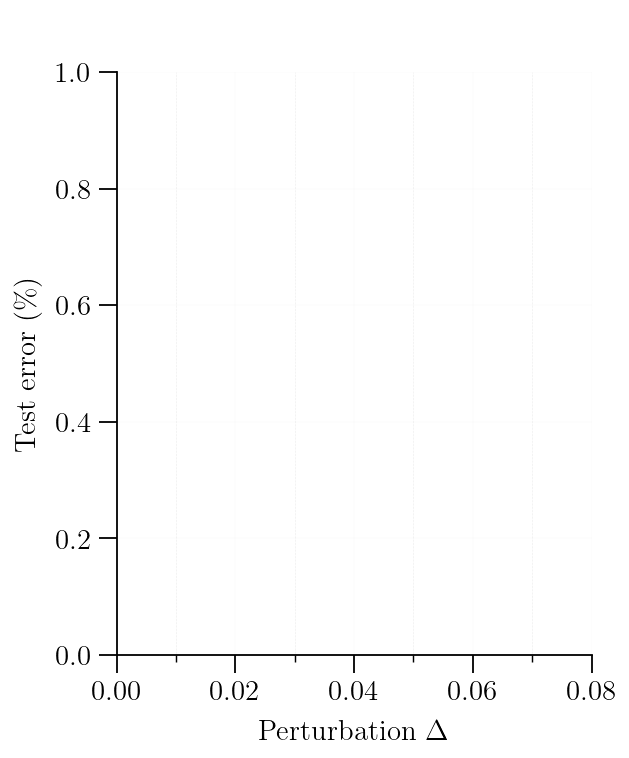

In [2]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

# ── LaTeX / font configuration ────────────────────────────────────────────────
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "xtick.major.size": 10,
    "ytick.major.size": 10,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
    "axes.spines.right": False,
    "axes.spines.top": False,
})

# ── Load results from combined JSON ──────────────────────────────────────────
# JSON_PATH = os.path.join(
#     os.path.dirname(os.path.abspath("__file__")),
#     "outputs_adversarial_multiclass_icnn",
#     "results_tau=0.05_epsent=0.02.json",
# )
JSON_PATH = "outputs_adversarial_multiclass_icnn/results_tau=0.05_epsent=0.02.json"

with open(JSON_PATH) as f:
    payload = json.load(f)

perturbation_levels = np.array(payload["perturbation_levels"])
epsilon_attack_values = payload["epsilon_attack_values"]
raw_results = payload["results"]  # {method_key: [{eps_str: accuracy%, ...}, ...]}

# Method key -> display name  (matches adversarial_multiclass_icnn.py conventions)
METHOD_DISPLAY = {
    "SAA":  "ERM",
    "WRM":  "Particle Ascent",
    "WGF":  "WGF(Otto, 1996)",
    "WFR":  "WFR(Xu, 2025)",
    "Dual": "Dual(Wang et al., 2021)",
    "SVG":  "SVG",
    "RGO":  "RGO",
    "ICNN": "ICNN",
    "PPA":  "PPA",
}

# Convert accuracy -> test error (%), averaging across runs
results = {}
for method_key, runs in raw_results.items():
    display_name = METHOD_DISPLAY.get(method_key, method_key)
    errors_matrix = []
    for run in runs:
        row = []
        for eps in epsilon_attack_values:
            eps_key = f"{eps:.10g}"
            acc = float(run.get(eps_key, 0.0))
            row.append(100.0 - acc)
        errors_matrix.append(row)
    errors = np.array(errors_matrix)
    results[display_name] = {
        "mean": np.mean(errors, axis=0),
        "std":  np.std(errors, axis=0),
        "n_runs": len(runs),
    }

print(f"Loaded {len(results)} methods: {list(results.keys())}")

# ── Style definitions (matching uncertain_least_squares_icnn.py) ──────────────
styles = {
    "ERM":                     {"color": "k",        "linestyle": "--"},
    "WGF(Otto, 1996)":         {"color": "#9a0ba7",   "linestyle": "-."},
    "WFR(Xu, 2025)":           {"color": "#ff69b4",   "linestyle": ":"}, #change WFR to be pink
    "Particle Ascent":         {"color": "#0eaf0e",   "linestyle": (0, (3, 1, 1, 1))},
    "Dual(Wang et al., 2021)": {"color": "#7A4E15",   "linestyle": (0, (5, 5))},
    "ICNN":                    {"color": "#1f77b4",   "linestyle": "--"},
    "SVG":                     {"color": "#ff7f0e",   "linestyle": (0, (1, 1))},
    "RGO":                     {"color": "#db2020",   "linestyle": (0, (5, 1))}, #change RGO to be red
    "PPA":                     {"color": "#00ced1",   "linestyle": (0, (3, 1, 1, 1, 1, 1))},
}

plot_order = [
    "ERM",
    "RGO",
    "WGF(Otto, 1996)",
    "WFR(Xu, 2025)",
    "Dual(Wang et al., 2021)",
    "Particle Ascent",
    "SVG",
    "ICNN",
    "PPA",
]

# ── Helper: plot all curves on a given axes ───────────────────────────────────
def _plot_curves(target_ax, with_label=True):
    for name in plot_order:
        if name not in results:
            continue
        mean = results[name]["mean"]
        std  = results[name]["std"]
        n    = results[name]["n_runs"]
        style = styles.get(name, {})
        kw = dict(linewidth=2.0, zorder=3, **style)
        if with_label:
            kw["label"] = name
        line, = target_ax.plot(perturbation_levels, mean, **kw)
        if n > 1:
            target_ax.fill_between(
                perturbation_levels,
                mean - std, mean + std,
                color=line.get_color(),
                alpha=0.18,
                linewidth=0,
            )

# ── Main plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.2, 6.5), dpi=130)
fig.subplots_adjust(left=0.1, right=0.97, bottom=0.13, top=0.82)

_plot_curves(ax, with_label=True)

# ── Axes labels & limits ──────────────────────────────────────────────────────
ax.set_xlabel(r"Perturbation $\Delta$", labelpad=8)
ax.set_ylabel(r"Test error (\%)", labelpad=8)

ax.set_xlim(float(perturbation_levels.min()), float(perturbation_levels.max()))

ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))

ax.tick_params(which="minor", length=4, width=0.8)

# ── Grid ──────────────────────────────────────────────────────────────────────
ax.grid(True, which="major", linestyle=":", linewidth=0.2, color="gray", alpha=0.2)
ax.grid(True, which="minor", linestyle=":", linewidth=0.3, color="gray", alpha=0.3)
ax.set_axisbelow(True)

# ── Legend (two rows, centered above the plot) ────────────────────────────────
handles, labels = ax.get_legend_handles_labels()
# Rename display labels
rename = {
    "ICNN": "WDRO-ICNN",
    "PPA":  "Projected Particle Ascent (PPA)",
    "WGF(Otto, 1996)": "WGF(Otto, 1996; Xu, 2025)",
}
labels = [rename.get(l, l) for l in labels]

legend = fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.54, 0.89),
    ncols=3,
    frameon=False,
    fontsize=7.5,
    handlelength=2.0,
    handletextpad=0.4,
    columnspacing=1.0,
    borderaxespad=0.0,
)

# ── Spines ────────────────────────────────────────────────────────────────────
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.savefig("./robustness_vs_delta_eps_0.02_LATEX.pdf", dpi=300, bbox_inches="tight")

plt.show()

Loaded 1 methods: ['NN-DRO']


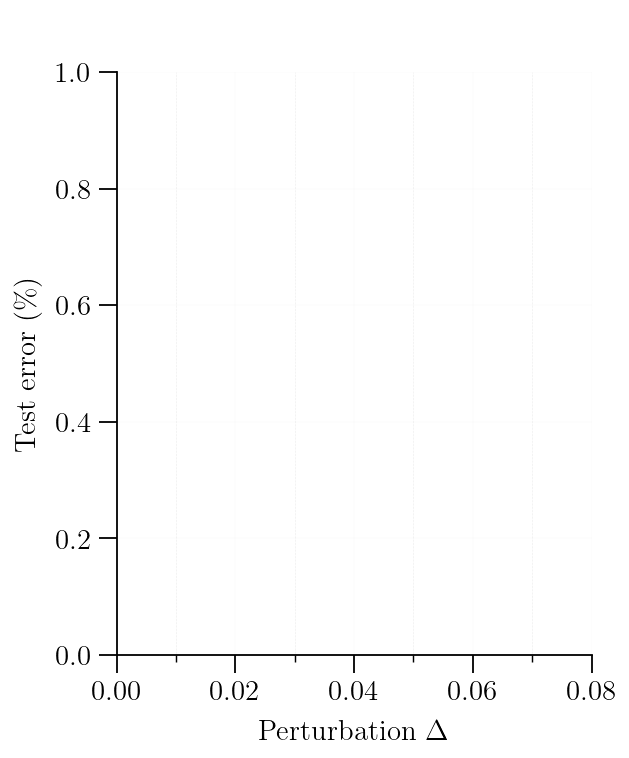

In [3]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

# ── LaTeX / font configuration ────────────────────────────────────────────────
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.labelsize": 16,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "xtick.major.size": 10,
    "ytick.major.size": 10,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
    "axes.spines.right": False,
    "axes.spines.top": False,
})

# ── Load results from combined JSON ──────────────────────────────────────────
# JSON_PATH = os.path.join(
#     os.path.dirname(os.path.abspath("__file__")),
#     "outputs_adversarial_multiclass_icnn",
#     "results_tau=0.05_epsent=0.02.json",
# )
JSON_PATH = "outputs_adversarial_multiclass_icnn/results_tau=0.05_epsent=0.002.json"

with open(JSON_PATH) as f:
    payload = json.load(f)

perturbation_levels = np.array(payload["perturbation_levels"])
epsilon_attack_values = payload["epsilon_attack_values"]
raw_results = payload["results"]  # {method_key: [{eps_str: accuracy%, ...}, ...]}

# Method key -> display name  (matches adversarial_multiclass_icnn.py conventions)
METHOD_DISPLAY = {
    "SAA":  "ERM",
    "WRM":  "Particle Ascent",
    "WGF":  "WGF(Otto, 1996)",
    "WFR":  "WFR(Xu, 2025)",
    "Dual": "Dual(Wang et al., 2021)",
    "SVG":  "SVG",
    "RGO":  "RGO",
    "ICNN": "ICNN",
    "PPA":  "PPA",
}

# Convert accuracy -> test error (%), averaging across runs
results = {}
for method_key, runs in raw_results.items():
    display_name = METHOD_DISPLAY.get(method_key, method_key)
    errors_matrix = []
    for run in runs:
        row = []
        for eps in epsilon_attack_values:
            eps_key = f"{eps:.10g}"
            acc = float(run.get(eps_key, 0.0))
            row.append(100.0 - acc)
        errors_matrix.append(row)
    errors = np.array(errors_matrix)
    results[display_name] = {
        "mean": np.mean(errors, axis=0),
        "std":  np.std(errors, axis=0),
        "n_runs": len(runs),
    }

print(f"Loaded {len(results)} methods: {list(results.keys())}")

# ── Style definitions (matching uncertain_least_squares_icnn.py) ──────────────
styles = {
    "ERM":                     {"color": "k",        "linestyle": "--"},
    "WGF(Otto, 1996)":         {"color": "#9a0ba7",   "linestyle": "-."},
    "WFR(Xu, 2025)":           {"color": "#ff69b4",   "linestyle": ":"}, #change WFR to be pink
    "Particle Ascent":         {"color": "#0eaf0e",   "linestyle": (0, (3, 1, 1, 1))},
    "Dual(Wang et al., 2021)": {"color": "#7A4E15",   "linestyle": (0, (5, 5))},
    "ICNN":                    {"color": "#1f77b4",   "linestyle": "--"},
    "SVG":                     {"color": "#ff7f0e",   "linestyle": (0, (1, 1))},
    "RGO":                     {"color": "#db2020",   "linestyle": (0, (5, 1))}, #change RGO to be red
    "PPA":                     {"color": "#00ced1",   "linestyle": (0, (3, 1, 1, 1, 1, 1))},
}

plot_order = [
    "ERM",
    "RGO",
    "WGF(Otto, 1996)",
    "WFR(Xu, 2025)",
    "Dual(Wang et al., 2021)",
    "Particle Ascent",
    "SVG",
    "ICNN",
    "PPA",
]

# ── Helper: plot all curves on a given axes ───────────────────────────────────
def _plot_curves(target_ax, with_label=True):
    for name in plot_order:
        if name not in results:
            continue
        mean = results[name]["mean"]
        std  = results[name]["std"]
        n    = results[name]["n_runs"]
        style = styles.get(name, {})
        kw = dict(linewidth=2.0, zorder=3, **style)
        if with_label:
            kw["label"] = name
        line, = target_ax.plot(perturbation_levels, mean, **kw)
        if n > 1:
            target_ax.fill_between(
                perturbation_levels,
                mean - std, mean + std,
                color=line.get_color(),
                alpha=0.18,
                linewidth=0,
            )

# ── Main plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.2, 6.5), dpi=130)
fig.subplots_adjust(left=0.1, right=0.97, bottom=0.13, top=0.82)

_plot_curves(ax, with_label=True)

# ── Axes labels & limits ──────────────────────────────────────────────────────
ax.set_xlabel(r"Perturbation $\Delta$", labelpad=8)
ax.set_ylabel(r"Test error (\%)", labelpad=8)

ax.set_xlim(float(perturbation_levels.min()), float(perturbation_levels.max()))

ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.01))

ax.tick_params(which="minor", length=4, width=0.8)

# ── Grid ──────────────────────────────────────────────────────────────────────
ax.grid(True, which="major", linestyle=":", linewidth=0.2, color="gray", alpha=0.2)
ax.grid(True, which="minor", linestyle=":", linewidth=0.3, color="gray", alpha=0.3)
ax.set_axisbelow(True)

# ── Legend (two rows, centered above the plot) ────────────────────────────────
handles, labels = ax.get_legend_handles_labels()
# Rename display labels
rename = {
    "ICNN": "WDRO-ICNN",
    "PPA":  "Projected Particle Ascent (PPA)",
    "WGF(Otto, 1996)": "WGF(Otto, 1996; Xu, 2025)",
}
labels = [rename.get(l, l) for l in labels]

legend = fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.54, 0.89),
    ncols=3,
    frameon=False,
    fontsize=7.5,
    handlelength=2.0,
    handletextpad=0.4,
    columnspacing=1.0,
    borderaxespad=0.0,
)

# ── Spines ────────────────────────────────────────────────────────────────────
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.savefig("./robustness_vs_delta_eps_0.002_LATEX.pdf", dpi=300, bbox_inches="tight")

plt.show()